In [1]:
'''
Project: Employee Retention Prediction - Salifort Motors
Author: Anabelle Rodríguez Rivero (belaria201@gmail.com - arodriguezrivero@gmail.com)
Role: Senior Data Engineer / ML Analyst
Description: End-to-end pipeline to identify high-risk turnover patterns 
             using Random Forest Classification.
'''

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score

In [2]:
# --- GLOBAL CONFIGURATION & VISUALIZATION SETTINGS ---
# Using a clean white style to maximize data-ink ratio in visualizations
sns.set_theme(style="white") 
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['axes.titlesize'] = 16

def visualize_correlations(df):
    """
    Generates a high-fidelity correlation heatmap for numerical features.
    
    Technical Approach:
    - Extracts numerical dtypes to compute the Pearson correlation matrix.
    - Applies a triangular mask to eliminate redundant upper-triangle data.
    - Utilizes the 'mako' perceptually uniform colormap for professional rendering.
    """
    # Filter numerical features for correlation analysis
    df_numeric = df.select_dtypes(include=[np.number])
    corr_matrix = df_numeric.corr()
    
    # Generate a mask for the upper triangle to reduce visual noise
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
    
    # Initialize the matplotlib figure
    plt.figure(figsize=(11, 9))
    
    # Render the heatmap with professional styling
    sns.heatmap(
        corr_matrix, 
        mask=mask, 
        annot=True, 
        cmap='mako', 
        fmt=".2f", 
        linewidths=.5, 
        cbar_kws={"shrink": .75}
    )
    
    plt.title('Correlation Matrix: Identifying Key Retention Drivers', pad=20)
    plt.show()

def load_and_audit_data(file_path):
    """
    Data Ingestion & Structural Integrity Audit.
    
    Workflow:
    1. Standardizes schema (snake_case normalization).
    2. Executes a deduplication pass to mitigate data leakage and bias.
    3. Triggers automated Exploratory Data Analysis (EDA).
    """
    # Standard Ingestion
    df = pd.read_csv(file_path)
    
    # Schema Normalization: Ensures consistent feature referencing
    df.columns = [col.strip().lower().replace(' ', '_') for col in df.columns]
    
    # Deduplication Pass: Critical for statistical integrity (approx. 20% of raw data)
    initial_record_count = len(df)
    df = df.drop_duplicates(keep='first')
    removed_records = initial_record_count - len(df)
    
    # Log audit results
    print(f"✅ AUDIT SUCCESS: Removed {removed_records} duplicate entries.")
    print(f"✅ DATA INTEGRITY: Final sample contains {len(df)} unique records.")
    
    # Trigger Exploratory Visuals
    visualize_correlations(df)
    
    return df

In [3]:
# --- FEATURE ENGINEERING ---

def preprocess_features(df):
    """Transform categorical data into numerical formats for ML ingestion."""
    df_processed = df.copy()
    
    # 1. Ordinal Encoding for Salary (Low < Medium < High)
    salary_map = {'low': 0, 'medium': 1, 'high': 2}
    df_processed['salary'] = df_processed['salary'].map(salary_map)
    
    # 2. One-Hot Encoding for Departments (Nominal Data)
    # drop_first=True avoids the Dummy Variable Trap
    df_processed = pd.get_dummies(df_processed, columns=['department'], drop_first=True)
    
    return df_processed

In [4]:
# --- MODELING STRATEGY ---

def train_and_evaluate(df):
    """Comparison between Baseline (Logistic) and Advanced (Random Forest) models."""
    X = df.drop('left', axis=1)
    y = df['left']
    
    # 80/20 Stratified Split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    
    print(f"Data for training: {len(X_train)}")
    print(f"Data for evaluation: {len(X_test)}")
    
    # Model A: Logistic Regression (Baseline)
    log_model = LogisticRegression(max_iter=1000)
    log_model.fit(X_train, y_train)
    
    # Model B: Random Forest (Optimized Solution)
    rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
    rf_model.fit(X_train, y_train)
    
    return X_test, y_test, log_model, rf_model

✅ AUDIT SUCCESS: Removed 3008 duplicate entries.
✅ DATA INTEGRITY: Final sample contains 11991 unique records.


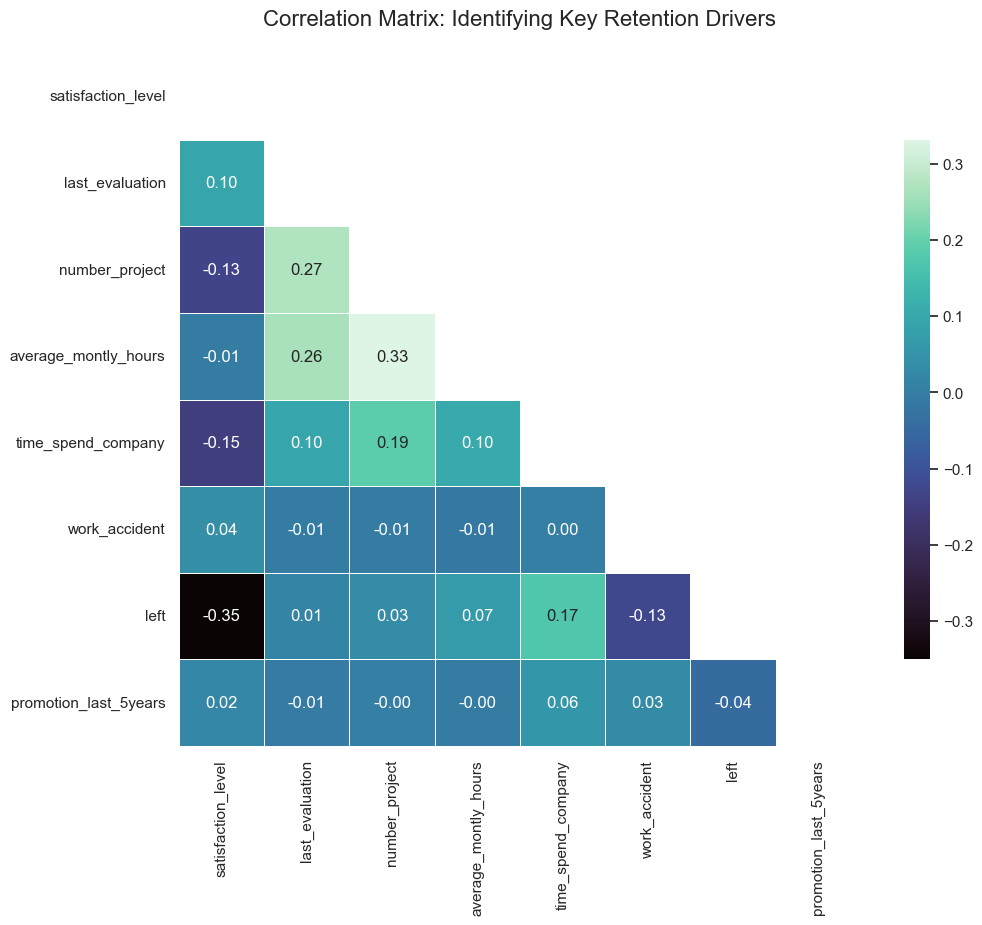

In [5]:
# --- EXECUTION ---

# 1. Ingestion
df_raw = load_and_audit_data('HR_comma_sep.csv')

In [6]:
# 2. Processing
df_final = preprocess_features(df_raw)

In [7]:
# 3. Training
X_test, y_test, log_baseline, rf_final = train_and_evaluate(df_final)

Data for training: 9592
Data for evaluation: 2399


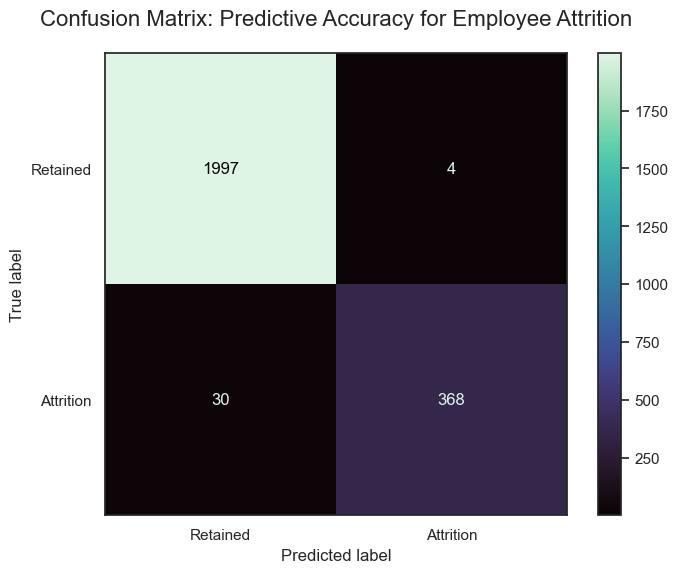

TP - True Positive: 368
FN - False Negative: 30
TN - True Negative: 1997
FP - False Positive: 4


In [8]:
# 4. Final Evaluation (Random Forest Results)
y_pred_rf = rf_final.predict(X_test)

# Defining professional labels
# 0 = Retained (Stayed), 1 = Attrition (Left)
professional_labels = ['Retained', 'Attrition']

# Plotting with professional aesthetics
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay.from_predictions(
    y_test, 
    y_pred_rf, 
    display_labels=professional_labels,
    cmap='mako', 
    ax=ax
)

plt.title('Confusion Matrix: Predictive Accuracy for Employee Attrition', pad=20)
plt.grid(False) # Heatmaps look better without the grid lines
plt.show()

#----------------
# Numerically speaking. : TP,FP,FN, TN
confusion_matrix(y_test, y_pred_rf)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_rf).ravel()
print("TP - True Positive:", tp)
print("FN - False Negative:", fn)
print("TN - True Negative:", tn)
print("FP - False Positive:", fp)
#----------------

In [9]:
print("\n--- FINAL MODEL PERFORMANCE: RANDOM FOREST ---")
print(classification_report(y_test, y_pred_rf))


--- FINAL MODEL PERFORMANCE: RANDOM FOREST ---
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      2001
           1       0.99      0.92      0.96       398

    accuracy                           0.99      2399
   macro avg       0.99      0.96      0.97      2399
weighted avg       0.99      0.99      0.99      2399



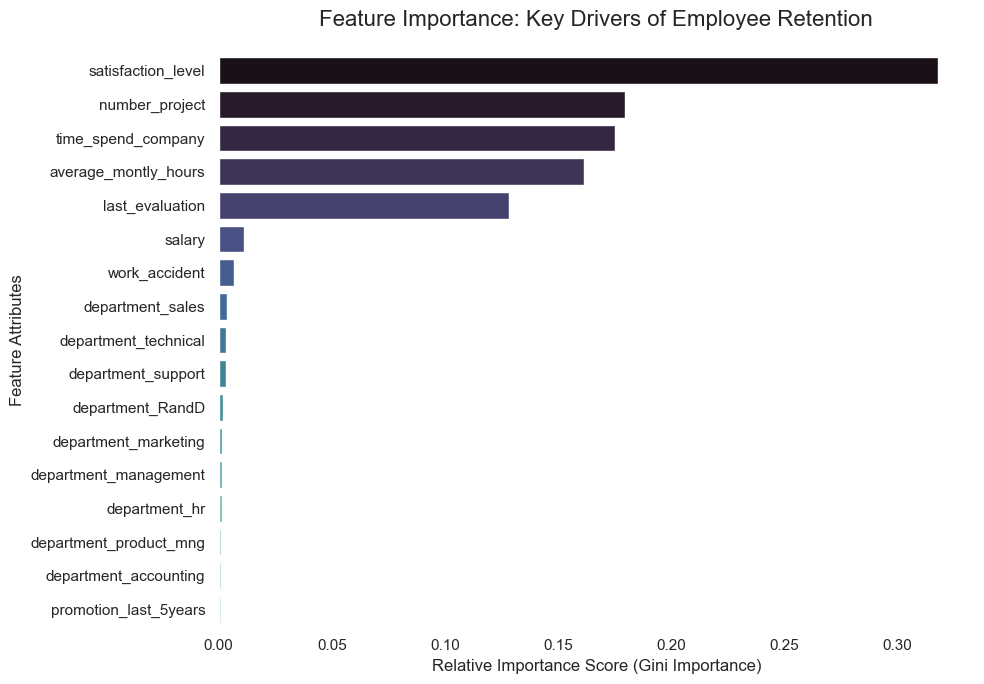

In [10]:
def plot_feature_importance(model, feature_names):
    """
    Computes and visualizes the relative importance of each feature 
    in the Random Forest model to identify key turnover drivers.
    """
    # Extracting Gini Importance scores
    importances = model.feature_importances_
    
    # Organizing data into a structured DataFrame
    feature_importance_df = pd.DataFrame({
        'Feature': feature_names, 
        'Importance': importances
    }).sort_values(by='Importance', ascending=False)

    # Professional Visualization Styling
    plt.figure(figsize=(10, 7))
    
    # Using 'hue' to fix the palette warning and 'mako' for visual consistency
    sns.barplot(
        data=feature_importance_df, 
        x='Importance', 
        y='Feature', 
        hue='Feature', 
        palette='mako', 
        legend=False
    )

    # Enhancing chart aesthetics for executive reporting
    plt.title('Feature Importance: Key Drivers of Employee Retention', fontsize=16, pad=20)
    plt.xlabel('Relative Importance Score (Gini Importance)', fontsize=12)
    plt.ylabel('Feature Attributes', fontsize=12)
    
    # Clean up the chart borders for a modern look
    sns.despine(left=True, bottom=True)
    
    plt.tight_layout()
    plt.show()

# --- EXECUTION ---
# We use X_test.columns because it's already in the global scope 
# and contains the exact same feature names as the original X.
plot_feature_importance(rf_final, X_test.columns)